<a href="https://colab.research.google.com/github/Kyrieligh/Yolo-Sleepy-Detection/blob/main/YOLO_sleepyDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics opencv-python roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


In [2]:
from roboflow import Roboflow

# Mengunduh dataset "asleep" versi 1 (Format Object Detection)
rf = Roboflow(api_key="UfmtwEcAhHP2xvNBYhqI")
project = rf.workspace("neural-network-project-jz3pl").project("asleep")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to asleep-1 in yolov8:: 100%|██████████| 2082/2082 [00:00<00:00, 2576.31it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from ultralytics import YOLO

# 1. Memuat model dasar YOLOv8 versi nano (Object Detection)
model_training = YOLO("yolov8n.pt")

# 2. Mulai proses training dengan dataset baru
# Kita gunakan 25 epoch untuk pengujian awal
model_training.train(data=f"{dataset.location}/data.yaml", epochs=25, imgsz=640)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/asleep-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e71488d1220>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [5]:
import cv2
import numpy as np
import base64
import time
from PIL import Image as PILImage
from IPython.display import display, HTML, clear_output
from google.colab.output import eval_js
from google.colab import files
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

print("Klik tombol 'Choose Files' di bawah ini untuk memasukkan file suara alarm (.mp3 / .wav):")
uploaded = files.upload()

# 3. Memproses file yang diunggah secara otomatis menjadi Base64
audio_b64 = ""
for filename, file_content in uploaded.items():
    # Mengubah isi file yang di-upload langsung menjadi string Base64
    audio_b64 = base64.b64encode(file_content).decode("utf-8")
    print(f"\n MANTAP! File '{filename}' berhasil diimpor sebagai suara alarm.")
    break # Hanya mengambil file pertama jika kamu memilih lebih dari satu

# 4. Fungsi untuk memutar musik alarm di browser
def play_custom_alarm():
    if not audio_b64:
        return # Jangan putar apapun jika belum ada file yang di-import

    js_sound = f"""
    var audio = new Audio("data:audio/mp3;base64,{audio_b64}");
    audio.play();
    """
    eval_js(js_sound)

Klik tombol 'Choose Files' di bawah ini untuk memasukkan file suara alarm (.mp3 / .wav):


Saving Suara Desahan.mp4 to Suara Desahan.mp4

 MANTAP! File 'Suara Desahan.mp4' berhasil diimpor sebagai suara alarm.


In [6]:
from IPython.display import Javascript

def take_photo(quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      const ctx = canvas.getContext('2d');
      ctx.drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      video.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js("takePhoto({})".format(quality))
    return data

def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, flags=1)
    return img

In [7]:
from base64 import b64decode

def start_streaming():
    while True:
        # 1. Ambil gambar dari webcam
        js = take_photo()
        img = js_to_image(js)

        # 2. Prediksi menggunakan YOLO
        results = model(img)[0]

        # Variabel penanda kondisi bahaya
        bahaya_terdeteksi = False

        # Daftar label dari dataset "asleep" yang dikategorikan mengantuk/berbahaya
        label_bahaya = ["drowsy", "asleep", "closed", "microsleep", "yawn"]

        # 3. Periksa setiap objek (kotak) yang ditemukan
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            label = model.names[cls]

            # Jika label termasuk dalam daftar bahaya dan akurasi di atas 55%
            if label.lower() in label_bahaya and conf > 0.55:
                bahaya_terdeteksi = True
                color = (0, 0, 255) # Kotak Merah
            else:
                color = (0, 255, 0) # Kotak Hijau untuk 'awake' atau 'no_yawn'

            # Gambar kotak objek dan teks nama labelnya
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, f"{label} {conf:.2f}", (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # 4. Logika Alarm Utama
        if bahaya_terdeteksi:
            play_custom_alarm() # Membunyikan file alarm.mp3
            cv2.putText(img, "PERINGATAN: PENGEMUDI MENGANTUK!", (20, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
        else:
            cv2.putText(img, "Status: AMAN", (20, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 3)

        # 5. Refresh layar output video
        clear_output(wait=True)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        display(PILImage.fromarray(img_rgb))

        # Batasi FPS agar stabil
        time.sleep(0.1)

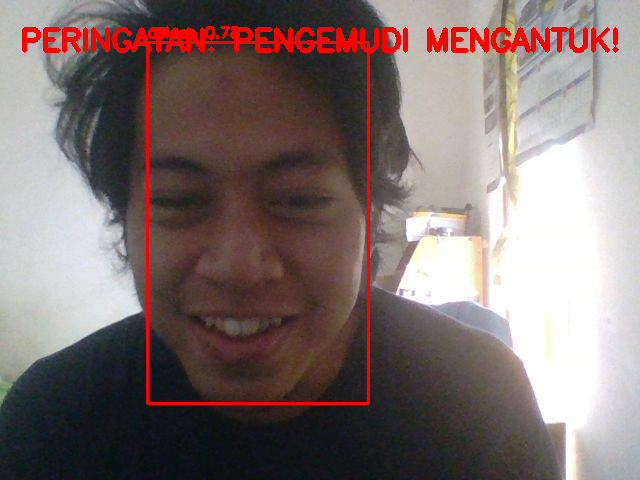

<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [9]:
# Jalankan ini untuk mulai menyalakan kamera dan mendeteksi kantuk secara real-time
start_streaming()